# Ridge Regression

In ridge regression, we add a regularization term to the usual ordinary least squares (OLS) regression to handle multicollinearity and prevent overfitting. The ridge regression model is defined by the equation:

$
\mathbf{w} = (\mathbf{X}^T \mathbf{X} + \lambda \mathbf{I})^{-1} \mathbf{X}^T \mathbf{y}
$

where:
- $ \mathbf{X} $ is the design matrix.
- $ \mathbf{y} $ is the response vector.
- $ \lambda $ is the regularization parameter.
- $ \mathbf{I} $ is the identity matrix of appropriate dimensions.

# Diabetes Dataset

Each of these 10 feature variables have been mean centered and scaled by the standard deviation times the square root of `n_samples` (i.e. the sum of squares of each column totals 1).

**Data Set Characteristics:**
Number of Instances: 442
Number of Attributes: First 10 columns are numeric predictive values

Target: Column 11 is a quantitative measure of disease progression one year after baseline

**Attribute Information:**
  - age     age in years
  - sex
  - bmi     body mass index
  - bp      average blood pressure
  - tc      total serum cholesterol
  - ldl     low-density lipoproteins
  - hdl     high-density lipoproteins
  - tch     total cholesterol / HDL
  - ltg     possibly log of serum triglycerides level
  - glu     blood sugar level

[Source URL](https://www4.stat.ncsu.edu/~boos/var.select/diabetes.html)

In [1]:
import pandas as pd
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
col_names = ['age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']
diabetes_df = pd.DataFrame(diabetes.data, columns=col_names)
diabetes_df.head()

,age,sex,bmi,bp,tc,ldl,hdl,tch,ltg,glu
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


<Axes: >

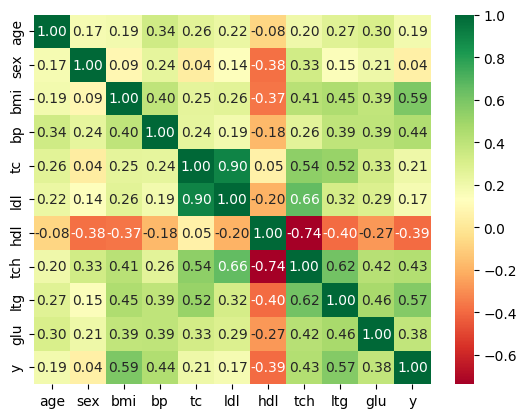

In [ ]:
from sklearn.datasets import load_diabetes
import seaborn as sns
diabetes = load_diabetes()
col_names = ['age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']
diabetes_df2 = pd.DataFrame(diabetes.data, columns=col_names)
diabetes_df2['y'] = diabetes.target
sns.heatmap(diabetes_df2.corr(), annot=True, fmt='.2f', cmap='RdYlGn')

## OLS: StatsModels API

In [3]:
import numpy as np
from scipy.stats import linregress
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Load the diabetes dataset
diabetes = load_diabetes()
col_names = ['age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']
diabetes_df = pd.DataFrame(diabetes.data, columns=col_names)
X = diabetes_df.values
y = diabetes.target  # Target variable (a quantitative measure of disease progression)

# Standardize the data
mean = np.mean(X, axis=0)
std_dev = np.std(X, axis=0)
X = (X - mean) / std_dev

X = np.hstack([np.ones((X.shape[0],1)), X])

X = pd.DataFrame(X, columns= ['const']+col_names)
# Fit the linear regression model
sm_model = sm.OLS(y, X)
results = sm_model.fit()

print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.518
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     46.27
Date:                Fri, 23 Jan 2026   Prob (F-statistic):           3.83e-62
Time:                        12:36:20   Log-Likelihood:                -2386.0
No. Observations:                 442   AIC:                             4794.
Df Residuals:                     431   BIC:                             4839.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.1335      2.576     59.061      0.0

## OLS: Using Numpy

In [ ]:
import numpy as np
from scipy.stats import linregress
from sklearn.datasets import load_diabetes
import matplotlib.pyplot as plt
import statsmodels.api as sm
import scipy.stats as stats

# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes_df
y = diabetes.target  # Target variable (a quantitative measure of disease progression)


# Standardize the data
mean = np.mean(X, axis=0)
std_dev = np.std(X, axis=0)
X = (X - mean) / std_dev

# Augmentation
X = np.hstack([np.ones((X.shape[0],1)), X])

# n samples, m features
n = X.shape[0]  # Number of samples
m = X.shape[1]  # Number of features (including intercept)

# (X'X)
X_transpose_X = X.T @ X

# (X'y)
X_transpose_y = X.T @ y

# inv(X'X)(X'y)
coefficients = np.linalg.inv(X_transpose_X)@(X_transpose_y)

# Compute the predictions
y_pred = np.dot(X, coefficients)

# Compute the residuals
residuals = y - y_pred

residual_variance = np.sum(residuals**2) / (n - m)

mse =  np.sum(residuals**2)/n
print(f"MSE: {mse:.2f}")

# Compute the covariance matrix
cov_matrix = residual_variance * np.linalg.inv(X_transpose_X)

# Standard errors of the coefficients
coeff_std_errors = np.sqrt(np.diag(cov_matrix))

# Confidence level
confidence_level = 0.95
z_score = stats.norm.ppf((1 + confidence_level) / 2)

# Calculate confidence intervals
conf_intervals = np.array([
    coefficients - z_score * coeff_std_errors,
    coefficients + z_score * coeff_std_errors
]).T

col_names = ['const', 'age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']
print(f"Feature:\tcoef\t\tstderr\t\tmin\t\tmax")
for i, (coef, conf_int) in enumerate(zip(coefficients, conf_intervals)):
    print(f"{col_names[i]}\t\t{coef:.2f}\t\t{coeff_std_errors[i]:.2f}\t\t{conf_int[0]:.2f}\t\t{conf_int[1]:.2f}")

MSE: 2859.70
Feature:	coef		stderr		min		max
const		152.13		2.58		147.08		157.18
age		-0.48		2.84		-6.05		5.09
sex		-11.41		2.91		-17.11		-5.70
bmi		24.73		3.16		18.52		30.93
bp		15.43		3.11		9.33		21.53
tc		-37.68		19.82		-76.53		1.17
ldl		22.68		16.13		-8.93		54.28
hdl		4.81		10.11		-15.01		24.62
tch		8.42		7.68		-6.63		23.48
ltg		35.73		8.18		19.71		51.76
glu		3.22		3.14		-2.93		9.37


## Ridge Regression: Using Numpy

In [5]:
from scipy import stats
# Load the diabetes dataset
diabetes = load_diabetes()
col_names = ['age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']
diabetes_df = pd.DataFrame(diabetes.data, columns=col_names)

X = diabetes_df
y = diabetes.target  # Target variable (a quantitative measure of disease progression)

# Standardize the data
mean = np.mean(X, axis=0)
std_dev = np.std(X, axis=0)
X = (X - mean) / std_dev

# Augmentation
X = np.hstack([np.ones((X.shape[0],1)), X])

# n samples, m features
n = X.shape[0]  # Number of samples
m = X.shape[1]  # Number of features (including intercept)

# Regularization parameter
lambda_ = 10.0

# Compute the ridge regression coefficients
X_transpose_X = X.T @ X
X_transpose_y = X.T @ y
identity_matrix = np.eye(m)
ridge_term = lambda_ * identity_matrix
coefficients = np.linalg.inv(X_transpose_X + ridge_term).dot(X_transpose_y)

# Compute the predictions
y_pred = np.dot(X, coefficients)

# Compute the residuals
residuals = y - y_pred

mse =  np.sum(residuals**2)/n
print(f"MSE: {mse:.2f}")
residual_variance = np.sum(residuals**2) / (n - m)

# Compute the covariance matrix
cov_matrix = residual_variance * np.linalg.inv(X_transpose_X)

# Standard errors of the coefficients
coeff_std_errors = np.sqrt(np.diag(cov_matrix))

# Confidence level
confidence_level = 0.95
z_score = stats.norm.ppf((1 + confidence_level) / 2)

# Calculate confidence intervals
conf_intervals = np.array([
    coefficients - z_score * coeff_std_errors,
    coefficients + z_score * coeff_std_errors
]).T

col_names = ['const', 'age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']
print(f"Feature:\tcoef\t\tstderr\t\tmin\t\tmax")
for i, (coef, conf_int) in enumerate(zip(coefficients, conf_intervals)):
    print(f"{col_names[i]}\t\t{coef:.2f}\t\t{coeff_std_errors[i]:.2f}\t\t{conf_int[0]:.2f}\t\t{conf_int[1]:.2f}")

MSE: 2883.53
Feature:	coef		stderr		min		max
const		148.77		2.59		143.70		153.84
age		-0.26		2.85		-5.85		5.34
sex		-10.94		2.92		-16.67		-5.21
bmi		24.60		3.18		18.37		30.83
bp		15.09		3.12		8.97		21.22
tc		-11.30		19.90		-50.30		27.71
ldl		1.81		16.19		-29.93		33.55
hdl		-6.56		10.15		-26.46		13.33
tch		5.60		7.71		-9.52		20.72
ltg		25.33		8.21		9.24		41.42
glu		3.52		3.15		-2.65		9.70


## Ridge Regression: Using Sklearn

In [6]:
from sklearn.linear_model import Ridge
from sklearn.datasets import load_diabetes
import pandas as pd
import statsmodels.api as sm

# Load the diabetes dataset
diabetes = load_diabetes()
col_names = ['age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']
diabetes_df = pd.DataFrame(diabetes.data, columns=col_names)

X = diabetes_df
y = diabetes.target  # Target variable (a quantitative measure of disease progression)

# Standardize the data
mean = np.mean(X, axis=0)
std_dev = np.std(X, axis=0)
X = (X - mean) / std_dev

# Augmentation
X = np.hstack([np.ones((X.shape[0],1)), X])

# Fit Ridge Regression model
ridge_model = Ridge(alpha=1.0, fit_intercept=True)
ridge_model.fit(X, y)

# Print coefficients
print(f"Feature:\tcoef")
print(f"const\t\t{ridge_model.intercept_:.2f}")
for i in range(len(col_names)):
    print(f"{col_names[i]}\t\t{ridge_model.coef_[i+1]:.2f}")

# Compute the predictions
y_pred = ridge_model.predict(X)
# Compute the residuals
residuals = y - y_pred
mse =  np.sum(residuals**2)/n
print(f"MSE: {mse:.2f}")

Feature:	coef
const		152.13
age		-0.43
sex		-11.33
bmi		24.77
bp		15.37
tc		-30.09
ldl		16.65
hdl		1.46
tch		7.52
ltg		32.84
glu		3.27
MSE: 2860.68


## Lasso Regression: Using SKLearn

In [7]:
from sklearn.linear_model import Lasso
from sklearn.datasets import load_diabetes
import pandas as pd
import statsmodels.api as sm
import numpy as np
# Load the diabetes dataset
diabetes = load_diabetes()
col_names = ['age', 'sex', 'bmi', 'bp', 'tc', 'ldl', 'hdl', 'tch', 'ltg', 'glu']
diabetes_df = pd.DataFrame(diabetes.data, columns=col_names)

X = diabetes_df
y = diabetes.target  # Target variable (a quantitative measure of disease progression)

# Standardize the data
mean = np.mean(X, axis=0)
std_dev = np.std(X, axis=0)
X = (X - mean) / std_dev

# Augmentation
X = np.hstack([np.ones((X.shape[0],1)), X])

# Fit Lasso model
lambda_ = 10
lasso_model = Lasso(alpha=lambda_, fit_intercept=True)
lasso_model.fit(X, y)

print(f"Feature:\tcoef")
print(f"x0\t\t{lasso_model.intercept_:.2f}")
for i in range(len(col_names)):
    print(f"{col_names[i]}\t\t{lasso_model.coef_[i]:.2f}")

# Compute the predictions
y_pred = lasso_model.predict(X)
# Compute the residuals
residuals = y - y_pred
n = X.shape[0]
mse =  np.sum(residuals**2)/n
print(f"MSE: {mse:.2f}")

Feature:	coef
x0		152.13
age		0.00
sex		0.00
bmi		-0.00
bp		22.60
tc		6.80
ldl		-0.00
hdl		-0.00
tch		-3.09
ltg		0.00
glu		19.59
MSE: 3209.93
